#### Import Libraries

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import  mean_squared_error,r2_score,mean_absolute_error,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [150]:
df = pd.read_csv("Advertising.csv")
print(df.describe())
df.head()

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [151]:
null_values = round((df.isnull().sum() / len(df)) * 100, 4).sort_values()

print(f"Missing values:\n{null_values}")
print("No null values")
print(".........................")

Missing values:
TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64
No null values
.........................


#### Scaling the Data set 

In [152]:
Scale = StandardScaler()

df_scaled = pd.DataFrame(Scale.fit_transform(df), columns=df.columns)
print("------------------------------------------------------")
print("After scaling Dataset making it range into -3 to 3 :")

df_scaled.head()


------------------------------------------------------
After scaling Dataset making it range into -3 to 3 :


,TV,Radio,Newspaper,Sales
0,0.969852,0.981522,1.778945,1.322319
1,-1.197376,1.082808,0.669579,-0.897515
2,-1.516155,1.528463,1.783549,-0.593948
3,0.052050,1.217855,1.286405,0.259834
4,0.394182,-0.841614,1.281802,0.525455


#### Training and Testing with mutli linear independent Dataset

In [153]:
X = df_scaled.iloc[:, :-1]
y = df_scaled.iloc[:, -1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)



#### Evaluation metrics

In [154]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

 
print("R² Score of Dataset:", r2)
print()
print("MAE of Dataset :", mae)
print()
print("MSE of Dataset:", mse)
print()
print("RMSE of dataset:", rmse)


R² Score of Dataset: 0.9115647723992758

MAE of Dataset : 0.2124957411568313

MSE of Dataset: 0.08653975484259227

RMSE of dataset: 0.2941764008933964


### Visualizing Error in Dataset

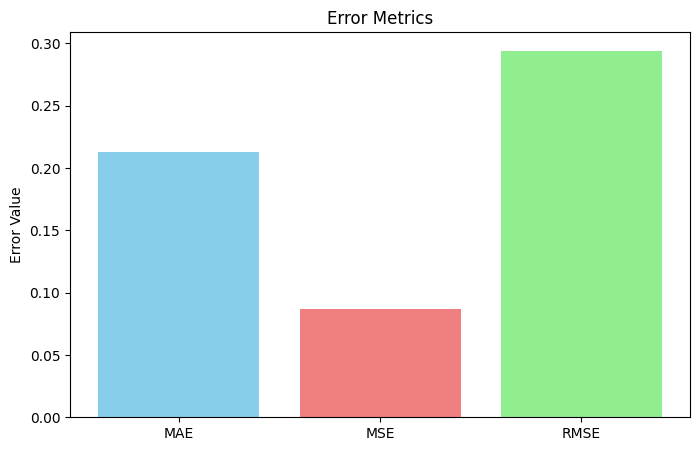

In [155]:
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]

plt.figure(figsize=(8,5))
plt.bar(metrics, values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title("Error Metrics")
plt.ylabel("Error Value")
plt.show()
